# Практическая работа
# Компьютерное зрение
# Обучение с передачей знаний для распознавания повреждений глазной сетчатки
## Преамбула
В этой практической работе вы попробуете построить модель глубокой нейронной сети для определения класса повреждения глазной сетчатки по снимкам ОКТ.

Однако, глубокие нейронные сети требовательны к большим объемам данных для сходимости обучения. И зачастую в нашей частной задаче недостаточно данных для того, чтобы хорошо натренировать все слои нейросети. `Transfer Learning` (`обучение переносом`) решает эту проблему.

`Transfer Learning` (`трансферное обучение`) — это подраздел машинного обучения, целью которого является применение знаний, полученные из одной задачи, к другой целевой задаче.

Для таких типовых задач, как классификация изображений, можно воспользоваться готовой архитектурой (AlexNet, VGG, Inception, ResNet и т.д.) и обучить нейросеть на своих данных. Реализации таких сетей с помощью различных фреймворков уже существуют, так что в этой работе мы будем использовать одну из них как черный ящик, не вникая глубоко в принцип её работы.

Нейронные сети, которые используются для классификации, как правило, содержат $N$ выходных нейронов в последнем слое, где $N$ — это количество классов. Такой выходной вектор трактуется как набор вероятностей принадлежности к классу. В нашей задаче количество классов может отличаться от того, которое было в исходном датасете. В таком случае нам придётся полностью выкинуть этот последний слой и поставить новый, с нужным количеством выходных нейронов.

![Текст ссылки](https://habrastorage.org/r/w1560/webt/u_/n3/k3/u_n3k3qpkps6nw9tjjzwc0njl-y.jpeg)

[Вспомогательные материалы](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

## Данные

`Оптическая когерентная томография сетчатки (ОКТ)` $-$ это метод визуализации, используемый для получения поперечных срезов сетчатки живых пациентов с высоким разрешением. Ежегодно выполняется около 30 миллионов ОКТ-сканирований, и анализ и интерпретация этих изображений занимает значительное количество времени (Swanson and Fujimoto, 2017).

![Текст ссылки](https://i.imgur.com/fSTeZMd.png)

На рисунке представлены классы повреждений сетчатки:

* (Крайний слева) неоваскуляризация хориоидеи (CNV) с неоваскулярной мембраной (белые стрелки) и связанной с ней субретинальной жидкостью (стрелки);
* (Средний слева) Диабетический макулярный отек (ДМЭ) с интраретинальной жидкостью, связанной с утолщением сетчатки (стрелки);
* (Справа посередине) Множественные друзы (наконечники стрел) присутствуют на ранних стадиях ВМД;
*(Крайний справа) Нормальная сетчатка с сохраненным контуром ямки и отсутствием какой-либо жидкости / отека сетчатки.

В этой задаче вы будете работать действительно с большим набором данных. Код для скачивания данных представлен ниже. Скачивание занимает в среднем 5 минут.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Aleggg\.cache\kagglehub\datasets\paultimothymooney\kermany2018\versions\2


In [2]:
import os # модуль для работы с операционной системой
os.listdir(path) # возвращает список вложенных в директорию с указанным путем объектов

['OCT2017']

Выберите директорию `OCT2017`. Лежащие в ней данные используйте для выполнения заданий.
Набор данных уже разделён на три выборки: `train`, `val` и `test`. Первые два поднабора будут использоваться для обучения, один $-$ для тестирования.

In [3]:
path = path + '\\OCT2017\\'

In [4]:
path

'C:\\Users\\Aleggg\\.cache\\kagglehub\\datasets\\paultimothymooney\\kermany2018\\versions\\2\\OCT2017\\'

In [5]:
# скажите, сколько файлов в каждом поднаборе
classes = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

for i in ['train', 'val', 'test']:
    print(i.upper())

    subset_total = 0

    for j in classes:

        cls_path = os.path.join(path, i, j)

        if os.path.exists(cls_path):
            count = len(os.listdir(cls_path))
            print(f"{j}:{count}")
            subset_total += count

TRAIN
CNV:37205
DME:11348
DRUSEN:8616
NORMAL:26315
VAL
CNV:8
DME:8
DRUSEN:8
NORMAL:8
TEST
CNV:242
DME:242
DRUSEN:242
NORMAL:242


## Построение модели

In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [8]:
# выберите устройство, на котором будете обучать нейронную сеть
# ResNet к т помню ее структуру ну и из-за скип конекшен

resnet50 = models.resnet50(
    weights="DEFAULT"
)
# resnet101 = resnet50.to(device)

В этой задаче загрузить данные достаточно просто, если использовать класс `torchvision.datasets.ImageFolder`.

Что нужно сделать:
* Задайте необходимую цепочку преобразований для картинок, используя `torchvision.transofoms`. Загляните в документацию к этому модулю и найдите преобразования: случайная обрезка (обрежьте случайным образом картинки до размера 224x224), случайный поворот, превратите в `torch.Tensor`, как делали это в предыдущей работе;

* Соберите три датасета с помощью `torchvision.datasets.ImageFolder`;

* Создайте три загрузчика данных (`torch.utils.data.DataLoader`). Для каждого из них укажите размер батча, укажите параметр, отвечающий за перетасовку изображений внутри каждой папки (нам не важен порядок картинок, поэтому случайная перетасовка уберёт лишние зависимости, которым может обучиться модель).

In [9]:
from PIL import Image

sample_path = path + '\\train\\' + '\\CNV\\' + '\\CNV-13823-1.jpeg'

img = Image.open(sample_path)

img.mode #1 канал

'L'

In [10]:
trans = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), #тк для resnet нужно 3 канала
    transforms.RandomResizedCrop(224),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.25, 0.25, 0.25]
    )
])

In [11]:
path

'C:\\Users\\Aleggg\\.cache\\kagglehub\\datasets\\paultimothymooney\\kermany2018\\versions\\2\\OCT2017\\'

In [12]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'train'),
    transform=trans
)

In [13]:
test_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'test'),
    transform=trans
)

In [14]:
val_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'val'),
    transform=trans
)

In [15]:
from torch.utils.data import DataLoader

In [16]:
batch = 16
workers = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch,
    shuffle=True,
    num_workers=workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch,
    shuffle=False,
    num_workers=workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch,
    shuffle=False,
    num_workers=workers,
    pin_memory=True
)

Покажите, какие изображения присутствуют в выборке. Напишите функцию `imshow`, выводящую на экран изображения в одном батче.

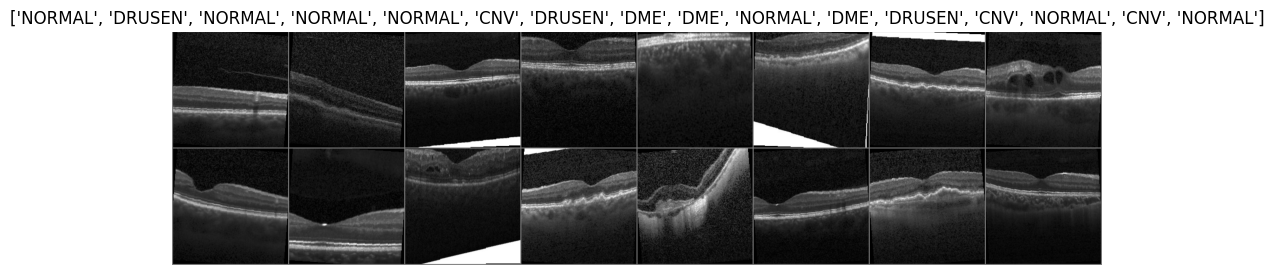

In [17]:
#тут подсмотрел т к замучился бы сам это писать((
def imshow(inp, title=None):
    if inp.dim() == 4:
        inp = torchvision.utils.make_grid(inp)
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    std = torch.tensor([0.25, 0.25, 0.25]).view(3,1,1)
    inp = inp * std + mean
    inp = inp.clamp(0, 1)
    plt.figure(figsize=(12, 8))
    plt.imshow(inp.permute(1, 2, 0))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def show_databatch(inputs, classes, class_names):
    out = torchvision.utils.make_grid(inputs)
    imshow(out, title=[class_names[x] for x in classes])

# next позволяет сделать один шаг вперёд по загрузчику данных
class_names = train_dataset.classes
inputs, classes = next(iter(train_loader))
show_databatch(inputs, classes, class_names)

Предобученная модель `VGG-16` способна классифицировать 1000 различных меток; нам просто нужно 4 вместо них. Чтобы сделать это, мы собираемся заменить последний полносвязный уровень модели на новый с 4 выходными нейронами вместо 1000.

В `PyTorch` мы можем получить доступ к классификатору `VGG-16` с помощью модуля `model.classifier`, который представляет собой 6-слойный массив. Мы заменим последнюю запись.

Скачайте и загрузите веса модели: [веса модели на kaggle](https://www.kaggle.com/datasets/pytorch/vgg16bn)

In [18]:
from torchvision import models

vgg16 = models.vgg16_bn()
vgg16.load_state_dict(torch.load("C:\\Users\\Aleggg\\Documents\\code\\cashePython\\vgg16_bn.pth"))
print(vgg16.classifier[6].out_features) # 1000

1000


In [19]:
# заморозьте все уровни модели vgg16
for param in vgg16.parameters():
    param.requires_grad = False

# затем добавьте новый слой
num_features = 4096# количество входных нейронов для 6-го слоя
features = list(vgg16.classifier.children())[:-1] # удаляем последний (выходной) слой
features.extend([nn.Linear(num_features, 4)]) # добавьте полносвязный слой с 4-мя нейронами
vgg16.classifier = nn.Sequential(*features) # замените модель на новую в атрибуте classifier
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Выберите оптимизатор обучения модели и функцию потерь.

Саму модель перенесите на `gpu`.

In [20]:
import torch.optim as optim

In [21]:
vgg16 = vgg16.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(vgg16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.1)

Напишите функции `train_model` для обучения и `eval_model` для оценки модели. Метрикой выберите `accuracy`. Предусмотрите, что эта модель может очень долго обучаться. Попробуйте предусмотреть сохранение весов очередной эпохи обучения и загрузку их в зависимости от какого-нибудь параметра параметра функции.

In [22]:
def eval_model(vgg, criterion, data):
  vgg.eval()
  total_loss = 0.0
  correct = 0
  total = 0
  
  with torch.no_grad():
    for inputs, labels in data:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = vgg(inputs)
      loss = criterion(outputs, labels)
      total_loss += loss.item()
      
      _, pred = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (pred == labels).sum().item()
  
  accuracy = 100 * correct / total
  avg_loss = total_loss / len(data)

  return avg_loss, accuracy

In [23]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=10, save_path="model.pth", load=True):

    model.to(device)
    start_epoch = 0

    if load and os.path.exists(save_path):

        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch'] + 1
        print(start_epoch)

    for epoch in range(start_epoch, epochs):
        
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        print(f"эпоха {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict()
        }, 
        save_path)

В конце оцените `accuracy` полученной модели.

In [24]:
train_model(
    model=vgg16,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    save_path="model1.pth",
    load=True
)

эпоха 1/10, Loss: 0.8305, Accuracy: 0.6844
эпоха 2/10, Loss: 0.8176, Accuracy: 0.6913
эпоха 3/10, Loss: 0.8271, Accuracy: 0.6877
эпоха 4/10, Loss: 0.8172, Accuracy: 0.6918
эпоха 5/10, Loss: 0.8211, Accuracy: 0.6896
эпоха 6/10, Loss: 0.8128, Accuracy: 0.6932
эпоха 7/10, Loss: 0.8206, Accuracy: 0.6896
эпоха 8/10, Loss: 0.8180, Accuracy: 0.6917
эпоха 9/10, Loss: 0.8156, Accuracy: 0.6933
эпоха 10/10, Loss: 0.8169, Accuracy: 0.6915


In [25]:
test_loss, test_acc = eval_model(vgg16, criterion, test_loader)
print(f"accuracy: {test_acc:.2f}%")

accuracy: 68.39%
